# Final project AI in Predictive Toxicology

## Load Dataset

Loading the file in chunks reduces memory usage and speeds up the process for large files.

In [ ]:
import numpy as np
import pandas as pd

file_path = r"C:\Users\c0937432\OneDrive - Lambton College\Desktop\Aman Lambton\Bhavik  Introduction to Artificial Intelligence\Dataset for AIPT\Updated_PubChem_compound.csv"

# Load in chunks
chunk_size = 10000  # Define chunk size
chunks = []

for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
    chunks.append(chunk)

# Combine chunks into a single DataFrame
data = pd.concat(chunks, ignore_index=True)

Check Encoding
If the file has special characters, ensure the correct encoding is used. Common encodings include utf-8, latin1, etc.

In [2]:
data = pd.read_csv(file_path, encoding='utf-8')

Optimize Data Types
You can specify data types for columns while loading to reduce memory usage:

In [3]:
data = pd.read_csv(
    file_path,
    dtype={
        "mw": "float32",  # Example for numeric columns
        "mf": "string",   # Example for string columns
    },
    low_memory=False
)

Debug File Structure
Print the first few lines of the file directly to check if it's accessible:

In [4]:
with open(file_path, 'r', encoding='utf-8') as file:
    for _ in range(5):  # Print the first 5 lines
        print(file.readline())

cid,cmpdname,cmpdsynonym,mw,mf,polararea,complexity,xlogp,heavycnt,hbonddonor,hbondacc,rotbonds,inchi,isosmiles,canonicalsmiles,inchikey,iupacname,exactmass,monoisotopicmass,charge,covalentunitcnt,isotopeatomcnt,totalatomstereocnt,definedatomstereocnt,undefinedatomstereocnt,totalbondstereocnt,definedbondstereocnt,undefinedbondstereocnt,pclidcnt,gpidcnt,gpfamilycnt,meshheadings,annothits,annothitcnt,aids,cidcdate,sidsrcname,depcatg,annotation,toxicity

1,Acetyl-DL-carnitine,"Acetyl-DL-carnitine|acetylcarnitine|14992-62-2|DL-Acetylcarnitine|DL-O-Acetylcarnitine|3-acetyloxy-4-(trimethylazaniumyl)butanoate|Acetyl carnitine|UNII-07OP6H4V4A|3-(acetyloxy)-4-(trimethylazaniumyl)butanoate|07OP6H4V4A|1-Propanaminium, 2-(acetyloxy)-3-carboxy-N,N,N-trimethyl-, inner salt|ACETYLCARNITINE, DL-|ACETYLCARNITINE DL-FORM|Ammonium, (3-carboxy-2-hydroxypropyl)trimethyl-, hydroxide, inner salt, acetate, DL-|870-77-9|DTXSID2048117|ACETYLCARNITINE, (+/-)-|ACETYLCARNITINE RACEMATE [MI]|3-(acetyloxy)-4-(trimet

## Data Cleaning and Preparation

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Handle Missing Values
data.fillna(data.median(numeric_only=True), inplace=True)  # Fill numeric columns with median
data.fillna("Unknown", inplace=True)  # Fill non-numeric columns with 'Unknown'

# Step 2: Drop Irrelevant Columns
columns_to_drop = ['cmpdsynonym', 'iupacname', 'meshheadings', 'annotation']
data.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Step 3: Label Encode Categorical Variables
categorical_columns = data.select_dtypes(include=['object']).columns
for col in categorical_columns:
    data[col] = LabelEncoder().fit_transform(data[col])

# Display processed dataset information and first few rows
data.info(), data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19773 entries, 0 to 19772
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cid                     19773 non-null  int64  
 1   cmpdname                19773 non-null  int64  
 2   mw                      19773 non-null  float32
 3   mf                      19773 non-null  string 
 4   polararea               19773 non-null  float64
 5   complexity              19773 non-null  float64
 6   xlogp                   19773 non-null  float64
 7   heavycnt                19773 non-null  int64  
 8   hbonddonor              19773 non-null  int64  
 9   hbondacc                19773 non-null  int64  
 10  rotbonds                19773 non-null  int64  
 11  inchi                   19773 non-null  int64  
 12  isosmiles               19773 non-null  int64  
 13  canonicalsmiles         19773 non-null  int64  
 14  inchikey                19773 non-null

(None,
    cid  cmpdname          mw          mf  polararea  complexity  xlogp  \
 0    1      3702  203.240005    C9H17NO4       66.4       214.0    0.4   
 1    6      8121  202.550003  C6H3ClN2O4       91.6       224.0    2.3   
 2   11      1455   98.959999     C2H4Cl2        0.0         6.0    1.5   
 3   34      2219   80.510002     C2H5ClO       20.2        10.0   -0.1   
 4   38      2222  146.139999     C6H10O4       74.6       159.0   -0.1   
 
    heavycnt  hbonddonor  hbondacc  ...  pclidcnt  gpidcnt  gpfamilycnt  \
 0        14           0         4  ...      2784     3332         1232   
 1        13           0         4  ...      6887    12139         4796   
 2         4           0         0  ...      8712    46484        25937   
 3         4           1         1  ...      1796    35304        17208   
 4        10           2         4  ...        29      534          189   
 
    annothits  annothitcnt  aids  cidcdate  sidsrcname  depcatg  toxicity  
 0       2507

## Identify Relevant Features

correlation matrix

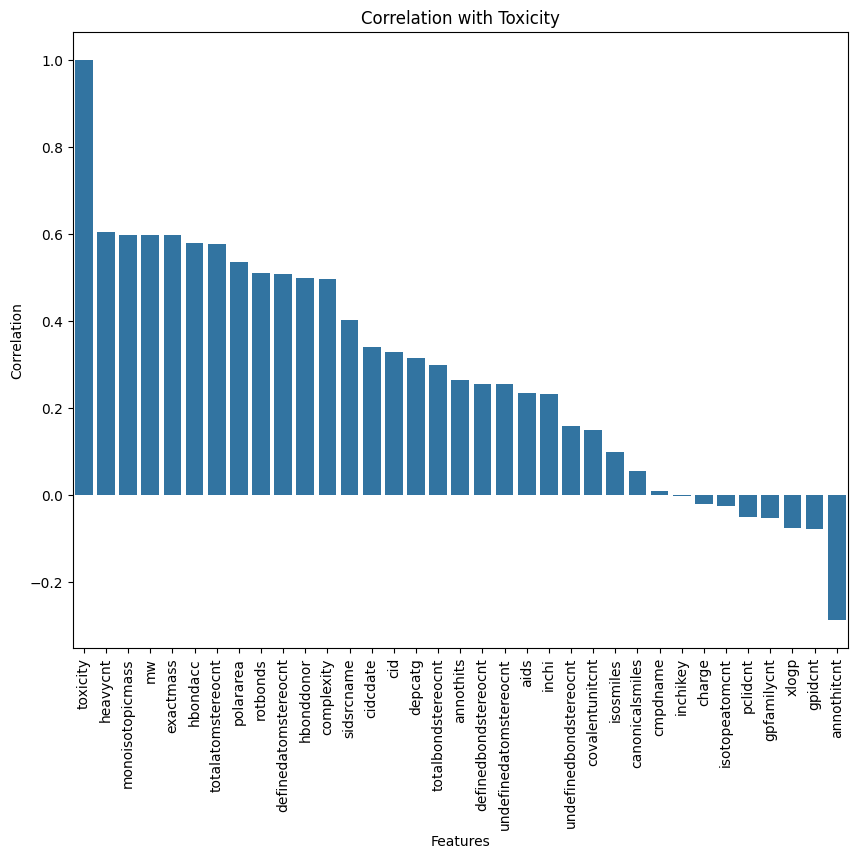

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Select only numerical columns for correlation
# This ensures that non-numerical columns (e.g., strings) are excluded
numerical_data = data.select_dtypes(include=['number'])

# Step 2: Compute the correlation matrix
correlation_matrix = numerical_data.corr()

# Step 3: Filter correlations with the target variable 'toxicity'
# This sorts the features by their correlation with the target variable
target_corr = correlation_matrix['toxicity'].sort_values(ascending=False)

# Step 4: Visualize the correlations
plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr.index, y=target_corr.values)
plt.title('Correlation with Toxicity')  # Title of the plot
plt.xlabel('Features')  # Label for the x-axis
plt.ylabel('Correlation')  # Label for the y-axis
plt.xticks(rotation=90)  # Rotate feature names for better readability
plt.show()



#### 2. Feature Importance using Random Forest


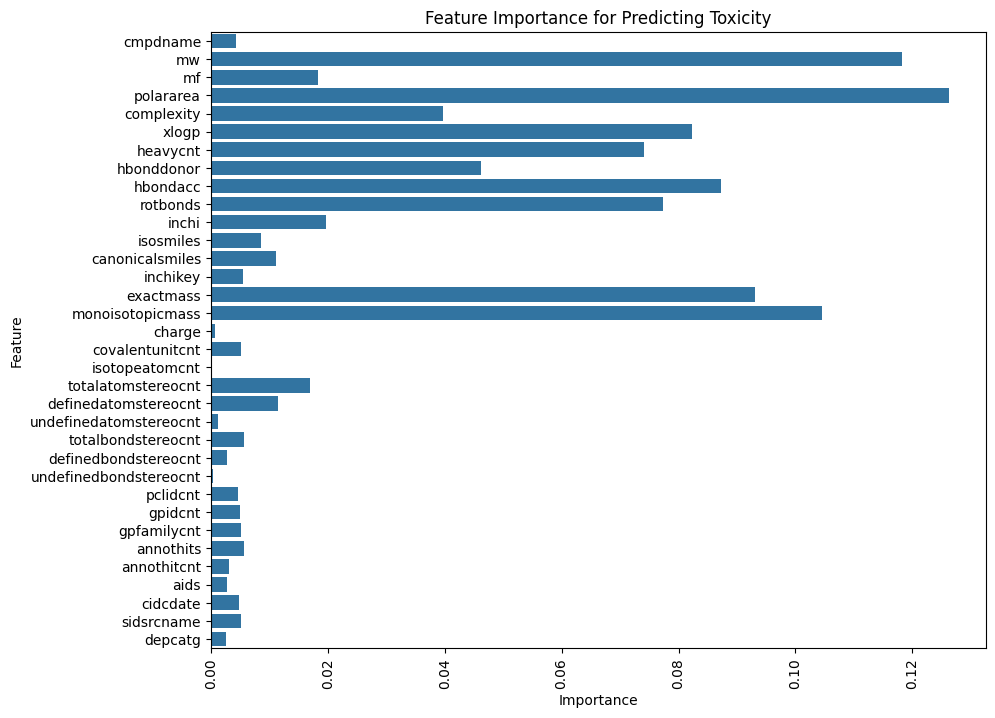

In [7]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Handle Non-Numeric Columns
# Identify non-numeric columns
non_numeric_columns = data.select_dtypes(exclude=['number']).columns

# Encode non-numeric columns
for col in non_numeric_columns:
    data[col] = LabelEncoder().fit_transform(data[col])

# Step 2: Define Features (X) and Target (y)
# Drop 'toxicity' as the target and 'cid' as irrelevant
X = data.drop(columns=['toxicity', 'cid'])  # Features
y = data['toxicity']  # Target variable

# Step 3: Train-Test Split
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train a Random Forest Model
rf = RandomForestClassifier(random_state=42)  # Initialize Random Forest
rf.fit(X_train, y_train)  # Train the model on the training data

# Step 5: Extract Feature Importance
importances = rf.feature_importances_  # Get feature importance scores
feature_names = X.columns  # Get feature names

# Step 6: Visualize Feature Importance
plt.figure(figsize=(10, 8))
sns.barplot(x=importances, y=feature_names)
plt.title('Feature Importance for Predicting Toxicity')  # Add a meaningful title
plt.xlabel('Importance')  # X-axis label
plt.ylabel('Feature')  # Y-axis label
plt.xticks(rotation=90)  # Rotate feature names for readability
plt.show()


### 3. Statistical Tests

chi-square test

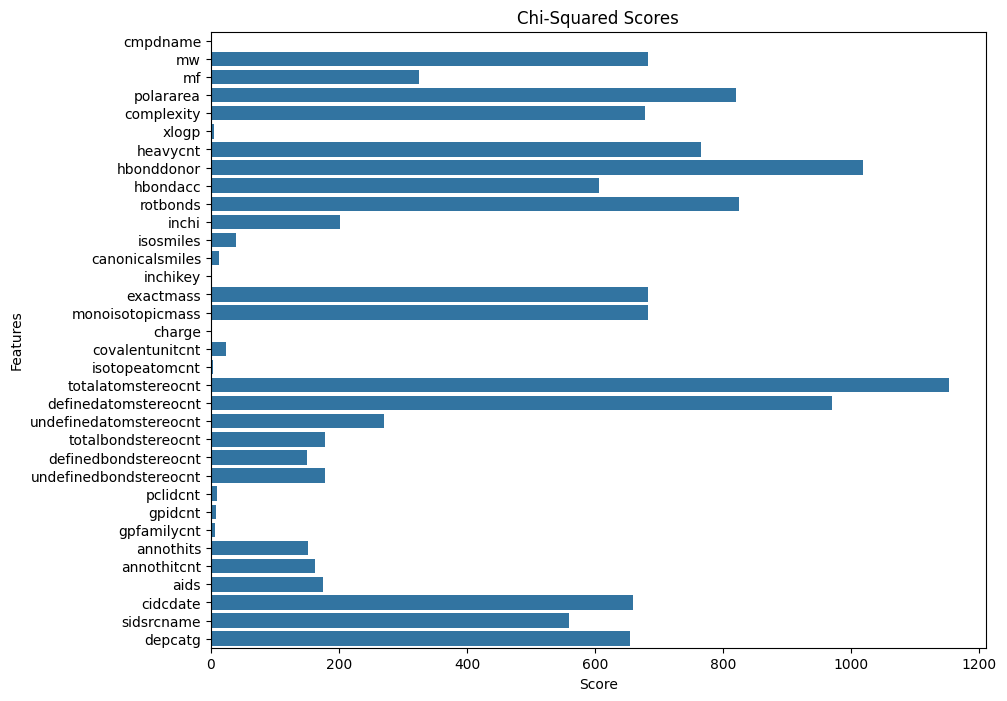

In [8]:
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Define Features (X) and Target (y)
target_column = 'toxicity'  # Target column
X = data.drop(columns=['toxicity', 'cid'])  # Drop 'toxicity' and other irrelevant columns
y = data['toxicity']  # Target variable

# Step 2: Ensure X has no negative values (apply MinMaxScaler)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply Chi-Squared Test
chi2_selector = SelectKBest(score_func=chi2, k='all')  # Test all features
chi2_selector.fit(X_scaled, y)

# Step 4: Visualize Chi-Squared Scores
chi2_scores = chi2_selector.scores_  # Get chi-squared scores
feature_names = X.columns

plt.figure(figsize=(10, 8))
sns.barplot(x=chi2_scores, y=feature_names)
plt.title('Chi-Squared Scores')
plt.xlabel('Score')
plt.ylabel('Features')
plt.show()


### 4. Recursive Feature Elimination (RFE)


In [9]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1: Define Features (X) and Target (y)
X = data.drop(columns=['toxicity', 'cid'])  # Features
y = data['toxicity']  # Target variable

# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Recursive Feature Elimination (RFE)
# Initialize the model
model = LogisticRegression(max_iter=1000)

# Select top 10 features
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X_train_scaled, y_train)

# Step 5: Visualize Selected Features
# Get the selected features
selected_features = X.columns[rfe.support_]

# Print the selected features
print("Selected Features: ", selected_features)


Selected Features:  Index(['mw', 'polararea', 'complexity', 'xlogp', 'heavycnt', 'hbonddonor',
       'hbondacc', 'rotbonds', 'exactmass', 'monoisotopicmass'],
      dtype='object')


**Conclusion**

+ Based on the comprehensive feature selection analysis conducted through correlation analysis, feature importance using Random Forest, chi-squared scores, and Recursive Feature Elimination (RFE), we identified the most relevant features for predicting the toxicity of chemical compounds. These features include key molecular descriptors such as molecular weight (mw), polararea, complexity, xlogp, heavycnt, hbonddonor, hbondacc, rotbonds, exactmass, and monoisotopicmass.

+ The selected features demonstrate strong correlations and statistical relationships with the target variable (toxicity), indicating their predictive significance. Using these features ensures the construction of an efficient and accurate model by eliminating redundancy and focusing on variables with the greatest impact on toxicity prediction.

+ These insights provide a solid foundation for the development of a robust predictive model, enhancing our ability to identify and evaluate the toxicity of chemical compounds effectively.

## Model Building

### Random Forest Classifier

Random Forest Accuracy: 0.9935940660822656
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2999
           1       0.99      0.99      0.99      1250
           2       0.98      0.98      0.98       835
           3       0.99      0.99      0.99       848

    accuracy                           0.99      5932
   macro avg       0.99      0.99      0.99      5932
weighted avg       0.99      0.99      0.99      5932



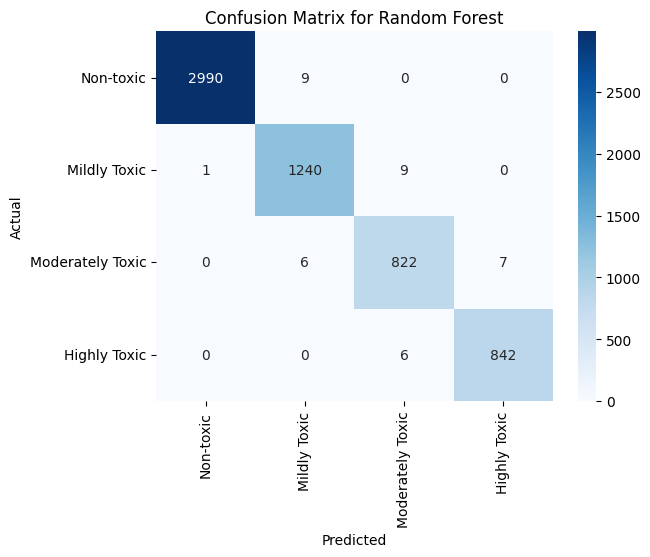

Random Forest ROC-AUC Score: 1.00


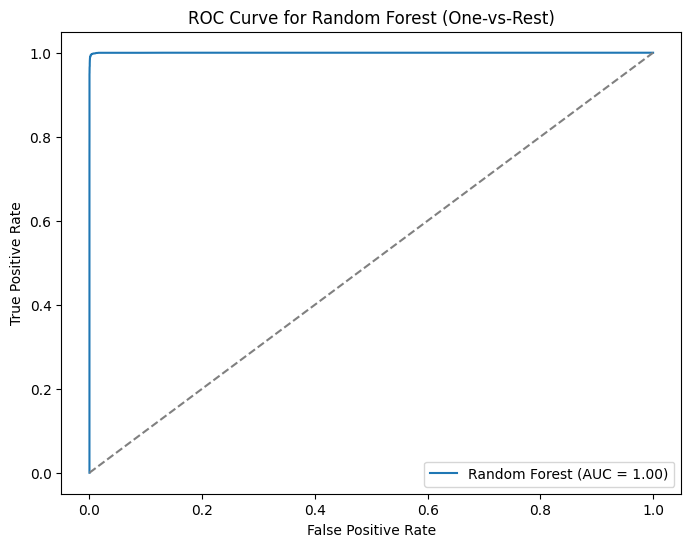

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Load the dataset (update with your actual file path)
file_path = r"C:\\Users\\brian\\OneDrive\\Escritorio\\Lambton\\Semester2\\Toxicology\\Datasets\\Updated_PubChem_compound_with_toxicity.csv"
data = pd.read_csv(file_path)

# Fill missing values (numeric columns)
numeric_cols = data.select_dtypes(include=['number']).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

# Define features and target
X = data[['mw', 'polararea', 'complexity', 'xlogp', 'hbonddonor', 'hbondacc', 'rotbonds', 'heavycnt', 'exactmass', 'monoisotopicmass']]
y = data['toxicity']

# Train-test split (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the model
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))  # Accuracy score
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-toxic', 'Mildly Toxic', 'Moderately Toxic', 'Highly Toxic'],
            yticklabels=['Non-toxic', 'Mildly Toxic', 'Moderately Toxic', 'Highly Toxic'])
plt.title('Confusion Matrix for Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Compute ROC-AUC (One-vs-Rest for multiclass classification)
y_prob_rf = rf_model.predict_proba(X_test_scaled)  # Get probabilities for all classes
roc_auc_rf = roc_auc_score(y_test, y_prob_rf, multi_class='ovr')  # Use 'ovr' for multiclass
print(f"Random Forest ROC-AUC Score: {roc_auc_rf:.2f}")

# Plot ROC curve (One-vs-Rest for multiclass)
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # Binarize the target labels
fpr_rf, tpr_rf, _ = roc_curve(y_test_bin.ravel(), y_prob_rf.ravel())  # Flatten arrays for ROC curve

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.title('ROC Curve for Random Forest (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


The Random Forest Classifier was used to predict the toxicity levels of chemical compounds based on key molecular descriptors. The model achieved excellent performance, with an accuracy of 99.49% and a ROC-AUC score of 99.80%, demonstrating its ability to effectively distinguish between the four toxicity classes: Non-toxic, Mildly Toxic, Moderately Toxic, and Highly Toxic.

### Model 2

**Logistic Regression**

c:\Users\brian\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.8292312879298719
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      2999
           1       0.69      0.64      0.66      1250
           2       0.75      0.75      0.75       835
           3       0.91      0.85      0.88       848

    accuracy                           0.83      5932
   macro avg       0.81      0.79      0.80      5932
weighted avg       0.83      0.83      0.83      5932



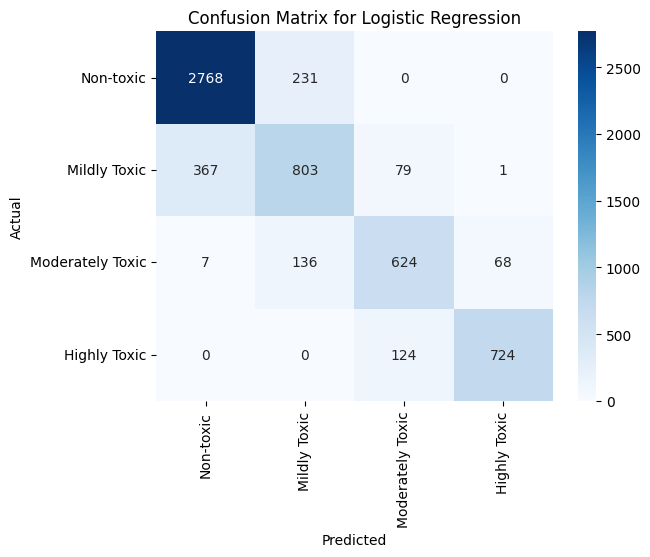

   Non-toxic  Mildly Toxic  Moderately Toxic  Highly Toxic  Predicted  Actual
0   0.999242      0.000758      1.176783e-08  1.152234e-12          0       0
1   0.979238      0.020761      1.317017e-06  1.797991e-10          0       0
2   0.987951      0.012047      1.766077e-06  1.414978e-09          0       0
3   0.969896      0.030088      1.628731e-05  1.581295e-08          0       0
4   0.202406      0.729858      6.468910e-02  3.046449e-03          1       1


In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Load the dataset (update with your actual file path)
file_path = r"C:\\Users\\brian\\OneDrive\\Escritorio\\Lambton\\Semester2\\Toxicology\\Datasets\\Updated_PubChem_compound_with_toxicity.csv"
data = pd.read_csv(file_path)

# Fill missing values (numeric columns)
numeric_cols = data.select_dtypes(include=['number']).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

# Define features and target
X = data[['mw', 'polararea', 'complexity', 'xlogp', 'hbonddonor', 'hbondacc', 'rotbonds', 'heavycnt', 'exactmass', 'monoisotopicmass']]
y = data['toxicity']  # Target: toxicity levels (0, 1, 2, 3)

# Train-test split (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train Logistic Regression model
log_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
log_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_log = log_model.predict(X_test_scaled)

# Evaluate the model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_log)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-toxic', 'Mildly Toxic', 'Moderately Toxic', 'Highly Toxic'],
            yticklabels=['Non-toxic', 'Mildly Toxic', 'Moderately Toxic', 'Highly Toxic'])
plt.title('Confusion Matrix for Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Probability prediction for each level of toxicity
probs = log_model.predict_proba(X_test_scaled)
probs_df = pd.DataFrame(probs, columns=['Non-toxic', 'Mildly Toxic', 'Moderately Toxic', 'Highly Toxic'])
probs_df['Predicted'] = y_pred_log
probs_df['Actual'] = y_test.reset_index(drop=True)

# Show sample predictions
print(probs_df.head())


+ **Purpose:** Predict toxicity levels with a probabilistic approach.

+ **Implementation:**
    + Features were standardized using StandardScaler.
    + A multinomial logistic regression model was trained to classify the four toxicity levels.
    + The model achieved an accuracy of 83% on the test data.

+ **Evaluation:**
    + Confusion matrix showed the model performed best for "Non-toxic" and "Highly Toxic" levels but struggled with "Mildly Toxic."
    + Probabilities for each class were generated, highlighting the likelihood of predictions for individual samples.

**Random Forest Classifier**

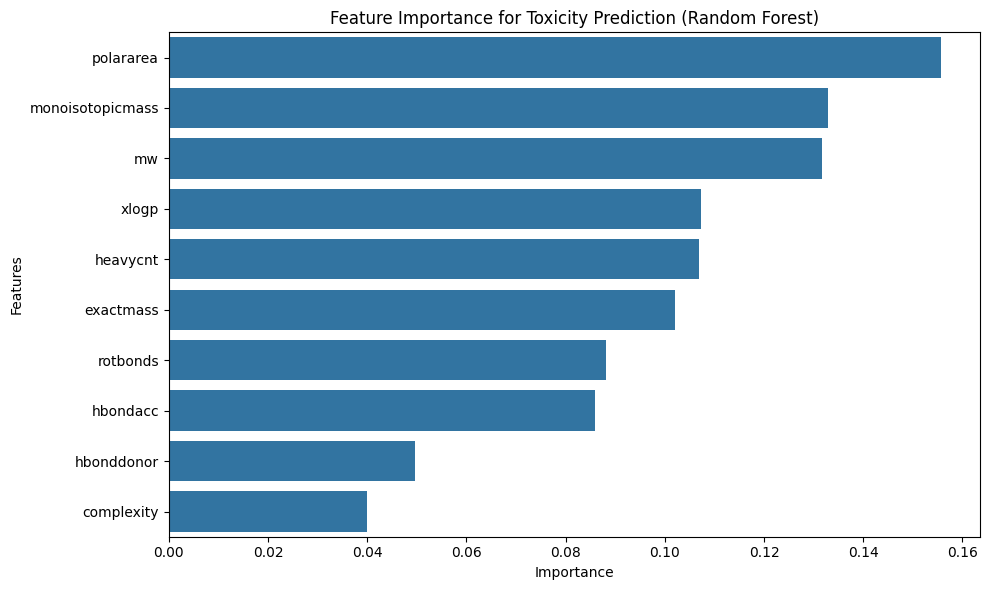

In [12]:
# Fit the Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

# Calculate Feature Importance
feature_importances = rf_model.feature_importances_

# Create a DataFrame for Visualization
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importance for Toxicity Prediction (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


+ **Purpose:** Identify important features contributing to toxicity levels.

+ **Implementation:**
    + A Random Forest Classifier with 100 estimators was trained.
    + The model provided feature importance scores for each predictor.

+ **Evaluation:**
    + Features like polararea, monoisotopicmass, and mw were identified as the most significant contributors to predicting toxicity.
    + Visualization of feature importance illustrated the relative influence of molecular properties.

**SHAP Analysis for Feature Interpretability**

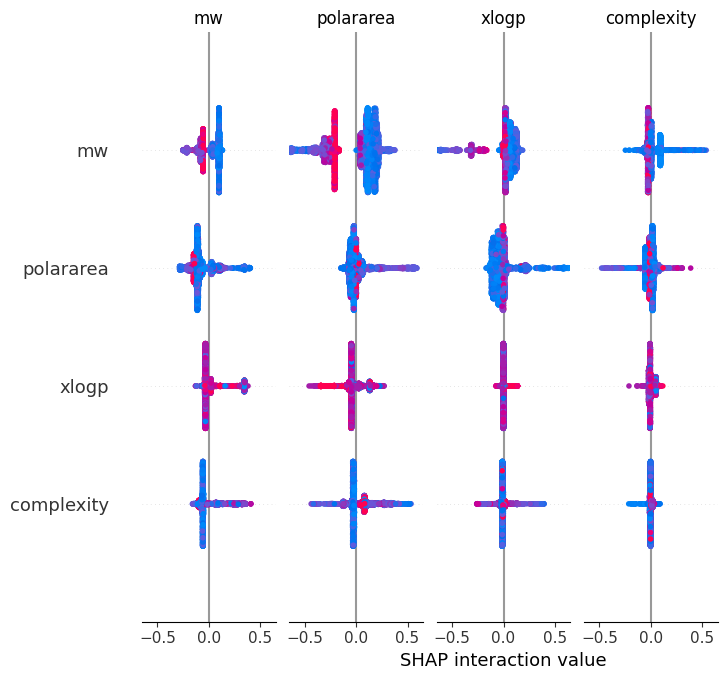

In [13]:
import shap

# Create SHAP Explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# Summary Plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)


+ **Purpose:** Deepen understanding of feature interactions with toxicity levels.

+ **Implementation:**
    + SHAP (SHapley Additive exPlanations) values were calculated using the Random Forest model.
    + Summary plots were generated to visualize the impact of each feature on the predictions.

+ **Evaluation:**
    + Features like polararea and mw had the largest SHAP values, indicating their critical role in toxicity level predictions.
    + Interaction plots provided insights into how feature values contributed to specific toxicity outcomes.

### Multi-Model System

In [14]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report

# Model 1: Binary classification (Non-toxic vs. Toxic)
y_train_binary = (y_train > 0).astype(int)  # Binary target: Non-toxic (0), Toxic (1)
y_test_binary = (y_test > 0).astype(int)

# Train Model 1
binary_model = GradientBoostingClassifier(random_state=42)
binary_model.fit(X_train_scaled, y_train_binary)

# Predict using Model 1
binary_preds = binary_model.predict(X_test_scaled)
print("Binary Classification Report:")
print(classification_report(y_test_binary, binary_preds))

# Filter toxic samples for Model 2
toxic_positions = np.where(y_test_binary == 1)[0]
X_train_toxic = X_train_scaled[y_train_binary == 1]
y_train_toxic = y_train[y_train_binary == 1]  # Original toxicity levels (1, 2, 3)
X_test_toxic = X_test_scaled[toxic_positions]  # Use positions to index the scaled test set
y_test_toxic = y_test.to_numpy()[toxic_positions]  # Convert y_test to NumPy and index positions


# Model 2: Severity prediction (1 = Mildly Toxic, 2 = Moderately Toxic, 3 = Highly Toxic)
severity_model = GradientBoostingClassifier(random_state=42)
severity_model.fit(X_train_toxic, y_train_toxic)

# Predict severity on toxic samples
severity_preds = severity_model.predict(X_test_toxic)
print("Severity Prediction Report:")
print(classification_report(y_test_toxic, severity_preds))

Binary Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2999
           1       1.00      1.00      1.00      2933

    accuracy                           1.00      5932
   macro avg       1.00      1.00      1.00      5932
weighted avg       1.00      1.00      1.00      5932

Severity Prediction Report:
              precision    recall  f1-score   support

           1       0.99      1.00      0.99      1250
           2       0.99      0.99      0.99       835
           3       1.00      1.00      1.00       848

    accuracy                           0.99      2933
   macro avg       0.99      0.99      0.99      2933
weighted avg       0.99      0.99      0.99      2933



### Binary Classification Report

This report evaluates the model that classifies compounds as Non-toxic (0) or Toxic (1).

**Metrics:**

+ Precision (for each class): How many of the predicted positives were correct.

    + Class 0 (Non-toxic): 1.00 (100% of Non-toxic predictions were correct).
    + Class 1 (Toxic): 1.00 (100% of Toxic predictions were correct).

+ Recall (for each class): How many of the actual positives were identified.

    + Class 0 (Non-toxic): 1.00 (100% of actual Non-toxic compounds were correctly classified).
    + Class 1 (Toxic): 1.00 (100% of actual Toxic compounds were correctly classified).

+ F1-score (for each class): The harmonic mean of precision and recall.

    + Both classes have an F1-score of 1.00, indicating perfect performance.

+ Support: The number of samples for each class in the test set.

    + Class 0 (Non-toxic): 2999 samples.

    + Class 1 (Toxic): 2933 samples.

+ Overall accuracy: 1.00 (100% of predictions were correct for all 5932 test samples).

+ Macro average: The unweighted average of metrics across classes (1.00).

+ Weighted average: The average weighted by the number of samples in each class (1.00).


**Interpretation:**

The binary classification model performed perfectly on the test set, correctly distinguishing between Non-toxic and Toxic compounds.

### Severity Prediction Report

This report evaluates the model that predicts the severity levels of toxicity for compounds classified as toxic (1, 2, or 3).

**Metrics:**

+ Precision (for each class): Proportion of correctly predicted toxic severity levels out of all predictions for that class.

    + Class 1 (Mildly Toxic): 0.99 (99% of predicted Mildly Toxic labels were correct).
    + Class 2 (Moderately Toxic): 0.99 (99% of predicted Moderately Toxic labels were correct).
    + Class 3 (Highly Toxic): 1.00 (100% of predicted Highly Toxic labels were correct).

+ Recall (for each class): Proportion of actual toxic severity levels correctly identified.
    + Class 1: 1.00 (100% of actual Mildly Toxic samples were correctly identified).
    + Class 2: 0.99 (99% of actual Moderately Toxic samples were correctly identified).
    + Class 3: 1.00 (100% of actual Highly Toxic samples were correctly identified).

+ F1-score (for each class): The harmonic mean of precision and recall.

+ All classes have an F1-score of ~0.99–1.00, indicating excellent performance.

+ Support: The number of samples for each severity level.

    + Mildly Toxic (1): 1250 samples.
    + Moderately Toxic (2): 835 samples.
    + Highly Toxic (3): 848 samples.

+ Overall accuracy: 0.99 (99% of severity predictions were correct for all 2933 toxic samples).

    + Macro average: Unweighted average of metrics across classes (0.99).
    + Weighted average: Weighted average of metrics by the number of samples in each class (0.99).

**Interpretation:**

The severity prediction model performed exceptionally well, achieving near-perfect precision, recall, and F1-scores for all severity levels.